# Estudo de dimensão — PCA + Regressão Logística

Aqui pegamos cada desenho 64×64 e reduzimos para k componentes via PCA
(k = 10, 20, 30, ...), treinando uma regressão logística em cada caso. Comparamos tudo com
o baseline: logística sobre os 4096 pixels originais.

A regressão logística é um modelo linear — serve de régua para a CNN, então o efeito que queremos estudar aparece de forma limpa.

## 1. Imports e parâmetros

In [2]:
import sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Caminho na minha máquina para os dados utilizados no projeto.
PROJETO = Path(r'C:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning')

sys.path.insert(0, str(PROJETO / 'treatments'))
from image_manipulation import load_images

In [ ]:
DADOS = PROJETO.parent
CAMINHO_CSV     = DADOS / 'master_doodle_dataframe.csv'
CAMINHO_IMAGENS = DADOS / 'doodle'
CAMINHO_JSON    = PROJETO / 'words_to_keep.json'

for p in (CAMINHO_CSV, CAMINHO_IMAGENS, CAMINHO_JSON):
    print('OK ' if p.exists() else 'FALTA ', p)

# Parâmetros
COMPONENTES         = [10, 20, 30, 50, 100, 200]
TARGET_SIZE         = (64, 64)
AMOSTRAS_POR_CLASSE = None

OK  C:\Users\guede\OneDrive\Área de Trabalho\codes\IML\master_doodle_dataframe.csv
OK  C:\Users\guede\OneDrive\Área de Trabalho\codes\IML\doodle
OK  C:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\words_to_keep.json


## 2. Carregar e filtrar o dataset

Lemos o CSV e ficamos só com as classes do words_to_keep.json.

In [4]:
with open(CAMINHO_JSON) as js:
    words_to_keep = json.load(js)
print('Classes:', words_to_keep)

df = pd.read_csv(CAMINHO_CSV)
df_filtrado = df[df['word'].isin(words_to_keep)]

if AMOSTRAS_POR_CLASSE is not None:
    df_filtrado = (df_filtrado.sample(frac=1, random_state=42)
                   .groupby('word', group_keys=False).head(AMOSTRAS_POR_CLASSE))

print('Total de imagens:', len(df_filtrado))
df_filtrado['word'].value_counts()

Classes: ['duck', 'drums', 'tree', 'megaphone', 'dog', 'piano', 'hot dog', 'door', 'hat', 'hurricane']
Total de imagens: 30000


word
door         3000
drums        3000
megaphone    3000
piano        3000
dog          3000
hurricane    3000
hat          3000
tree         3000
duck         3000
hot dog      3000
Name: count, dtype: int64

## 3. Carregar as imagens (com diagnóstico)

In [5]:
caminhos = (pd.Series(df_filtrado['image_path'].values)
            .str.replace(r'^data[\\/]', '', regex=True).values)

imagens = load_images(caminhos, base_path=str(CAMINHO_IMAGENS), target_size=TARGET_SIZE)

planas = imagens.reshape(len(imagens), -1)
falhas = int(np.sum(planas.sum(axis=1) == 0))
if falhas:
    print(f'[AVISO] {falhas}/{len(imagens)} imagens estão vazias')
else:
    print('OK')

X = planas.astype(np.float32)
encoder = LabelEncoder()
y = encoder.fit_transform(df_filtrado['word'].values)
print('X:', X.shape, '| classes:', list(encoder.classes_))

OK
X: (30000, 4096) | classes: ['dog', 'door', 'drums', 'duck', 'hat', 'hot dog', 'hurricane', 'megaphone', 'piano', 'tree']


### Alguns desenhos...


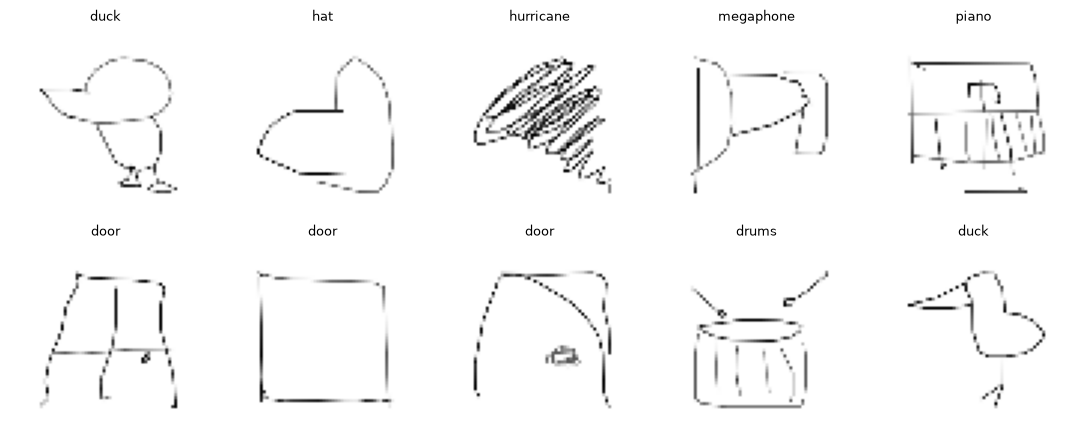

In [6]:
fig, axs = plt.subplots(2, 5, figsize=(11, 4.5))
for ax, idx in zip(axs.ravel(), np.random.default_rng(0).integers(0, len(X), 10)):
    ax.imshow(X[idx].reshape(TARGET_SIZE), cmap='gray')
    ax.set_title(encoder.classes_[y[idx]], fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Split + padronização

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print('treino:', X_train_s.shape, '| teste:', X_test_s.shape)

treino: (24000, 4096) | teste: (6000, 4096)


## 5. PCA — variância explicada

Ajustamos o PCA uma vez com o maior k. Os primeiros k componentes são os mesmos para
qualquer truncamento, então depois é só fatiar colunas. A curva abaixo mostra quanta informação
cada componente acrescenta — aqui podemos reparar como ela satura.

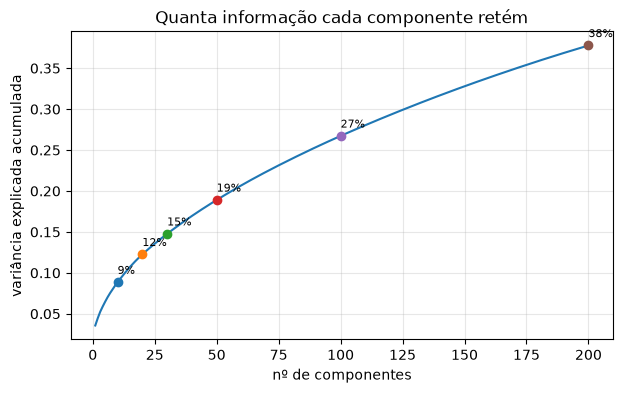

In [8]:
k_max = max(COMPONENTES)
pca = PCA(n_components=k_max, random_state=42)
X_train_full = pca.fit_transform(X_train_s)
X_test_full  = pca.transform(X_test_s)

acumulada = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(range(1, k_max + 1), acumulada, '-')
for k in COMPONENTES:
    plt.scatter(k, acumulada[k-1], zorder=3)
    plt.annotate(f'{acumulada[k-1]:.0%}', (k, acumulada[k-1]),
                 textcoords='offset points', xytext=(0, 6), fontsize=8)
plt.xlabel('nº de componentes'); plt.ylabel('variância explicada acumulada')
plt.title('Quanta informação cada componente retém'); plt.grid(alpha=0.3); plt.show()

### Como a imagem fica reconstruída em cada dimensão:

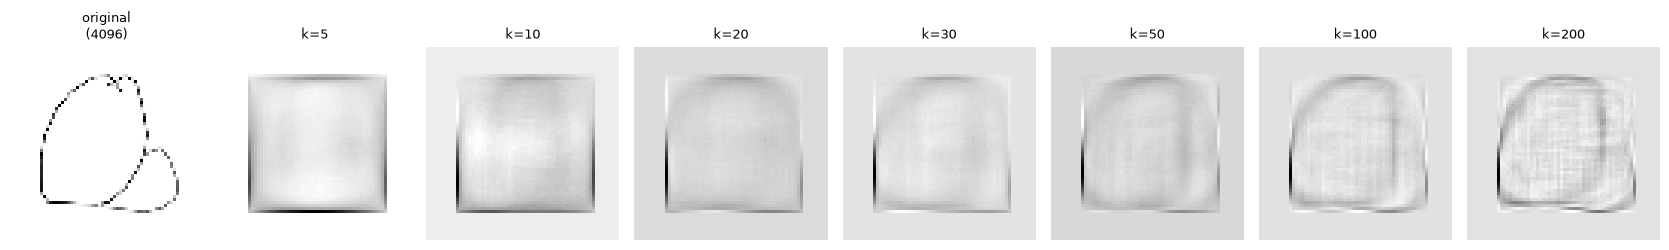

In [9]:
exemplo = X_test[0]
exemplo_s = scaler.transform(exemplo.reshape(1, -1))
proj = pca.transform(exemplo_s)

ks = [5] + COMPONENTES
fig, axs = plt.subplots(1, len(ks) + 1, figsize=(2.1 * (len(ks) + 1), 2.4))
axs[0].imshow(exemplo.reshape(TARGET_SIZE), cmap='gray'); axs[0].set_title('original\n(4096)', fontsize=9)
axs[0].axis('off')
for ax, k in zip(axs[1:], ks):
    recon_s = proj[:, :k] @ pca.components_[:k] + pca.mean_
    recon = scaler.inverse_transform(recon_s)
    ax.imshow(recon.reshape(TARGET_SIZE), cmap='gray')
    ax.set_title(f'k={k}', fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Treinar logística em cada dimensão

Baseline (4096 pixels) + uma logística para cada k. Guardamos acurácia, F1-macro e tempo.

In [10]:
def treinar(rotulo, Xtr, Xte):
    t0 = time.time()
    clf = LogisticRegression(max_iter=1000, n_jobs=-1)
    clf.fit(Xtr, y_train)
    dt = time.time() - t0
    return {'dimensoes': rotulo, 'n_features': Xtr.shape[1],
            'acc_treino': accuracy_score(y_train, clf.predict(Xtr)),
            'acc_teste':  accuracy_score(y_test,  clf.predict(Xte)),
            'f1_macro_teste': f1_score(y_test, clf.predict(Xte), average='macro'),
            'tempo_s': round(dt, 2)}

resultados = [treinar('todos (4096)', X_train_s, X_test_s)]
for k in COMPONENTES:
    r = treinar(k, X_train_full[:, :k], X_test_full[:, :k])
    r['variancia_explicada'] = float(pca.explained_variance_ratio_[:k].sum())
    resultados.append(r)
    print(f"k={k:>4} -> acc_teste={r['acc_teste']:.3f}  f1={r['f1_macro_teste']:.3f}  ({r['tempo_s']}s)")

df_result = pd.DataFrame(resultados)
df_result

c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


k=  10 -> acc_teste=0.614  f1=0.610  (0.75s)


c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


k=  20 -> acc_teste=0.651  f1=0.647  (0.99s)


c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


k= 100 -> acc_teste=0.689  f1=0.687  (2.01s)


c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


k= 200 -> acc_teste=0.695  f1=0.692  (3.84s)


,dimensoes,n_features,acc_treino,acc_teste,f1_macro_teste,tempo_s,variancia_explicada
0,todos (4096),4096,0.911625,0.542000,0.539318,117.33,NaN
1,10,10,0.620208,0.613833,0.609664,0.75,0.088564
2,20,20,0.653833,0.651333,0.647460,0.99,0.122584
3,30,30,0.674958,0.663500,0.661129,1.57,0.147675
4,50,50,0.686292,0.681000,0.678411,1.91,0.189073
5,100,100,0.701583,0.689167,0.686654,2.01,0.267299
6,200,200,0.717250,0.694667,0.692329,3.84,0.377754


## 7. Curva Acurácia x Dimensão

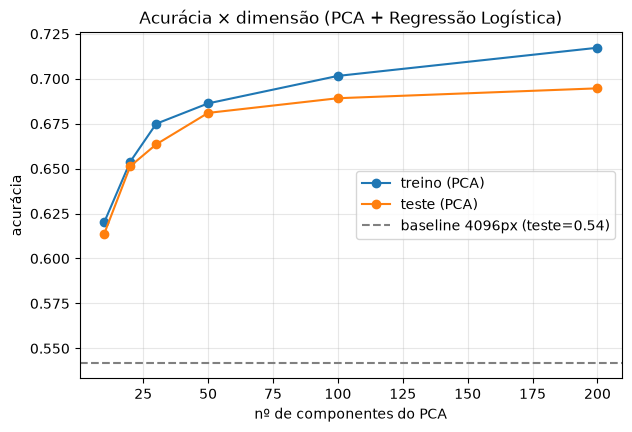

In [11]:
df_pca = df_result[df_result['dimensoes'] != 'todos (4096)']
base = df_result.iloc[0]

plt.figure(figsize=(7, 4.5))
plt.plot(df_pca['n_features'], df_pca['acc_treino'], 'o-', label='treino (PCA)')
plt.plot(df_pca['n_features'], df_pca['acc_teste'],  'o-', label='teste (PCA)')
plt.axhline(base['acc_teste'], color='gray', ls='--',
            label=f"baseline 4096px (teste={base['acc_teste']:.2f})")
plt.xlabel('nº de componentes do PCA'); plt.ylabel('acurácia')
plt.title('Acurácia × dimensão (PCA + Regressão Logística)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Matriz de confusão



c:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


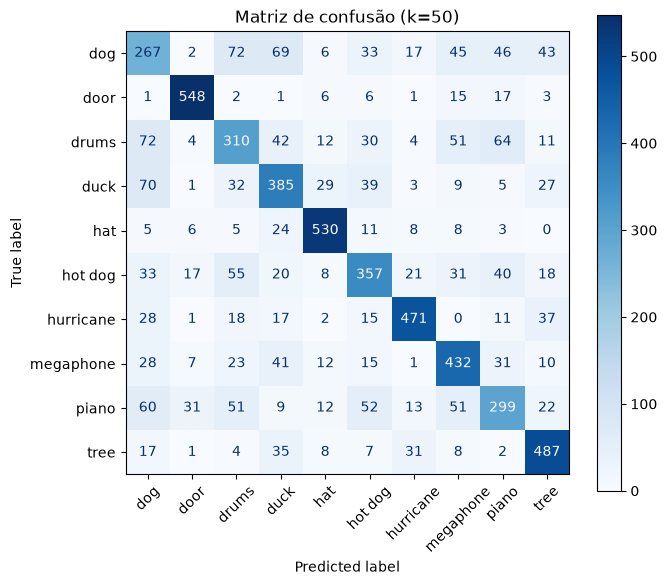

In [12]:
K_ESCOLHIDO = 50
clf = LogisticRegression(max_iter=1000, n_jobs=-1).fit(X_train_full[:, :K_ESCOLHIDO], y_train)
pred = clf.predict(X_test_full[:, :K_ESCOLHIDO])

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=encoder.classes_).plot(ax=ax, xticks_rotation=45, cmap='Blues')
ax.set_title(f'Matriz de confusão (k={K_ESCOLHIDO})'); plt.tight_layout(); plt.show()

In [13]:
saida = PROJETO / 'estudo_dimensoes_RL' / 'output'; saida.mkdir(exist_ok=True)
df_result.to_csv(saida / 'resultado_pca_logistica.csv', index=False)
print('Salvo em', saida / 'resultado_pca_logistica.csv')

Salvo em C:\Users\guede\OneDrive\Área de Trabalho\codes\IML\Projeto-Machine-Learning\estudo_dimensoes_RL\output\resultado_pca_logistica.csv


Modelos prontos para k = [10, 20, 30, 50, 100, 200]
Testando: megaphone.png


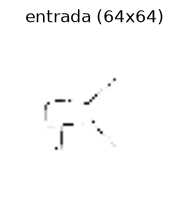

,PCA (k),top-3
0,10,"megaphone (40%), duck (37%), hat (9%)"
1,20,"duck (51%), megaphone (33%), hat (6%)"
2,30,"duck (50%), megaphone (33%), hat (8%)"
3,50,"duck (47%), megaphone (31%), hat (15%)"
4,100,"duck (54%), megaphone (32%), hat (7%)"
5,200,"duck (59%), megaphone (29%), hat (5%)"


In [ ]:
# Treina e GUARDA uma logística por dimensão de PCA (as células de cima descartavam o modelo)
clf_por_k = {k: LogisticRegression(max_iter=1000).fit(X_train_full[:, :k], y_train)
             for k in COMPONENTES}
print('Modelos prontos para k =', list(clf_por_k))


def prever_top3(caminho_imagem, top=3, mostrar=True):
    """Recebe o caminho de uma imagem (qualquer tamanho, ex. 255x255), redimensiona
    para 64x64 e mostra os `top` palpites do modelo para cada dimensão de PCA."""
    caminho = Path(caminho_imagem)

    # mesmo pré-processamento do treino (cinza -> 64x64 -> /255), reusando load_images
    vec = (load_images([caminho.name], base_path=str(caminho.parent), target_size=TARGET_SIZE)
           .reshape(1, -1).astype(np.float32))
    if vec.sum() == 0:
        print('[AVISO] imagem vazia/não encontrada — confira o caminho:', caminho)
        return

    if mostrar:
        plt.figure(figsize=(2.2, 2.2))
        plt.imshow(vec.reshape(TARGET_SIZE), cmap='gray'); plt.axis('off')
        plt.title('entrada (64x64)'); plt.show()

    # mesma transformação: padroniza e projeta no PCA (k_max), depois fatia por k
    proj = pca.transform(scaler.transform(vec))

    linhas = []
    for k, clf in clf_por_k.items():
        probs = clf.predict_proba(proj[:, :k])[0]
        idx = np.argsort(probs)[::-1][:top]
        nomes = encoder.inverse_transform(clf.classes_[idx])
        palpites = ', '.join(f'{n} ({probs[i]:.0%})' for n, i in zip(nomes, idx))
        linhas.append({'PCA (k)': k, f'top-{top}': palpites})
    return pd.DataFrame(linhas)


#imagem de teste: troque SÓ o nome do arquivo abaixo 
PASTA_TESTE  = PROJETO / 'estudo_dimensoes_RL' / 'input-teste'
IMAGEM_TESTE = 'megafonenovo.png'   # troque aqui 

print('Testando:', IMAGEM_TESTE)
prever_top3(PASTA_TESTE / IMAGEM_TESTE)

## 11. Data Augmentation + novo treino + teste nas suas imagens

imagens variam em posição, tamanho e ângulo — e a logística nos pixels não tem invariância a isso.
O data augmentation gera cópias deslocadas, giradas e reescaladas das imagens de treino, para o
modelo aprender a tolerar essas variações. Seguimos com PCA + Regressão Logística; só enriquecemos o treino.

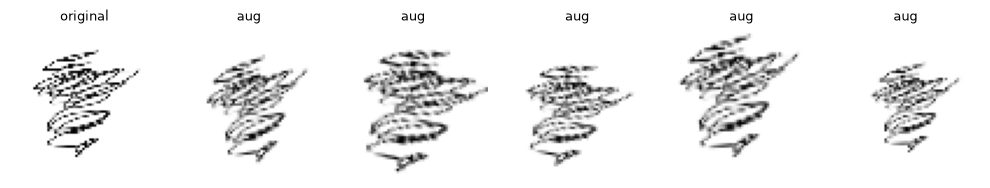

treino: 24000 -> aumentado: 72000
acc teste COM augmentation (k=50): 0.626


In [ ]:
import cv2 as cv

def augmenta(img, rng):
    """Gera uma versão deslocada, girada e reescalada do desenho (fundo branco = 1)."""
    h, w = img.shape
    ang = rng.uniform(-15, 15); esc = rng.uniform(0.8, 1.2)
    tx, ty = rng.uniform(-6, 6), rng.uniform(-6, 6)
    M = cv.getRotationMatrix2D((w / 2, h / 2), ang, esc); M[0, 2] += tx; M[1, 2] += ty
    return cv.warpAffine(img, M, (w, h), borderValue=1.0)

rng = np.random.default_rng(42)
img_train = X_train.reshape(-1, *TARGET_SIZE)

fig, axs = plt.subplots(1, 6, figsize=(10, 2))
axs[0].imshow(img_train[0], cmap='gray'); axs[0].set_title('original', fontsize=9); axs[0].axis('off')
for a in axs[1:]:
    a.imshow(augmenta(img_train[0], rng), cmap='gray'); a.set_title('aug', fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

# expande o TREINO: originais + N_AUG cópias aumentadas de cada
N_AUG = 2
blocos, labels = [X_train], [y_train]
for _ in range(N_AUG):
    blocos.append(np.array([augmenta(im, rng) for im in img_train]).reshape(len(img_train), -1))
    labels.append(y_train)
X_train_aug = np.vstack(blocos).astype(np.float32)
y_train_aug = np.concatenate(labels)
print('treino:', len(X_train), '-> aumentado:', len(X_train_aug))

# mesmo pipeline (StandardScaler + PCA + Logística), só que treinado nos dados aumentados
K_AUG = 50
scaler_a = StandardScaler().fit(X_train_aug)
Xtr_a = scaler_a.transform(X_train_aug).astype(np.float32)
pca_a = PCA(n_components=K_AUG, random_state=42).fit(Xtr_a)
clf_aug = LogisticRegression(max_iter=1000).fit(pca_a.transform(Xtr_a), y_train_aug)

acc_aug = accuracy_score(y_test, clf_aug.predict(pca_a.transform(scaler_a.transform(X_test).astype(np.float32))))
print(f'acc teste COM augmentation (k={K_AUG}): {acc_aug:.3f}')

Testando (modelo com augmentation): chapeu.png


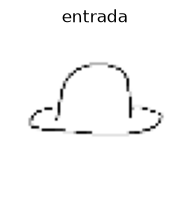

,classe,prob
0,megaphone,49%
1,piano,27%
2,hot dog,17%


In [75]:
PASTA_TESTE = PROJETO / 'estudo_dimensoes_RL' / 'input-teste'

def prever_aug(caminho_imagem, top=3, mostrar=True):
    """Prediz com o modelo treinado COM data augmentation (PCA + logística)."""
    caminho = Path(caminho_imagem)
    vec = (load_images([caminho.name], base_path=str(caminho.parent), target_size=TARGET_SIZE)
           .reshape(1, -1).astype(np.float32))
    if vec.sum() == 0:
        print('[AVISO] imagem não encontrada:', caminho); return
    if mostrar:
        plt.figure(figsize=(2.2, 2.2)); plt.imshow(vec.reshape(TARGET_SIZE), cmap='gray')
        plt.axis('off'); plt.title('entrada'); plt.show()
    probs = clf_aug.predict_proba(pca_a.transform(scaler_a.transform(vec)))[0]
    idx = np.argsort(probs)[::-1][:top]
    return pd.DataFrame({'classe': encoder.inverse_transform(clf_aug.classes_[idx]),
                         'prob': [f'{probs[i]:.0%}' for i in idx]})

IMAGEM_TESTE = 'chapeu.png'   # troque aqui (ex.: 'hotdog.png', 'piano.png')
print('Testando (modelo com augmentation):', IMAGEM_TESTE)
prever_aug(PASTA_TESTE / IMAGEM_TESTE)